In [1]:
from SPARQLWrapper import SPARQLWrapper, JSON
import rdflib as rdf
import pandas as pd
import pprint
import re
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
from branca.colormap import LinearColormap
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ds2022 = pd.read_csv(filepath_or_buffer="./rilevazione-flusso-veicoli-tramite-spire-anno-2022.csv", sep=";")

In [24]:
pprint.pprint(ds2022.head(4))

         data   codice spira  00:00-01:00  01:00-02:00  02:00-03:00  \
0  2022-10-02  3.96 3.88 2 1          270          150          112   
1  2022-10-02   4.2 4.48 2 1          234          159          110   
2  2022-10-02   4.4 4.48 6 1          214          156          100   
3  2022-10-02  4.6 0.127 8 1           86           53           41   

   03:00-04:00  04:00-05:00  05:00-06:00  06:00-07:00  07:00-08:00  ...  \
0           76           66           76          141          192  ...   
1           74           75          104          157          137  ...   
2           56           40           55           73          113  ...   
3           18           26           37           99           52  ...   

     ordinanza  stato  codimpsem  direzione  angolo  longitudine  latitudine  \
0  4000/343434      A        248         SO   147.0    11.371840   44.511646   
1  4000/343434      A        400        NaN    85.0    11.383961   44.493397   
2  4000/343434      A       

In [ ]:
# HEATMAP CREATION

def normalize_name(s):
    s = str(s).lower().strip()
    s = unicodedata.normalize('NFKD', s)
    return s

files = [
    'rilevazione-autoveicoli-tramite-spire-anno-2019.csv',
    'rilevazione-autoveicoli-tramite-spire-anno-2020.csv',
    'rilevazione-autoveicoli-tramite-spire-anno-2021.csv',
    'rilevazione-flusso-veicoli-tramite-spire-anno-2022.csv',
    'rilevazione-flusso-veicoli-tramite-spire-anno-2023.csv',
    'rilevazione-flusso-veicoli-tramite-spire-anno-2024.csv',
    'rilevazione-flusso-veicoli-tramite-spire-anno-2025.csv'
]

for file in files:
    ds_geo = pd.read_csv(file, sep=';', parse_dates=['data'])
    year = file[-8:-4]
    hour_cols = [c for c in ds_geo.columns if ':' in c]
    ds_geo['daily_total'] = ds_geo[hour_cols].sum(axis=1)
    spire_avg = ds_geo.groupby('codice spira')['daily_total'].mean().reset_index().rename(columns={'daily_total':'value'})

    road_avg = ds_geo[['codice spira', 'Nome via']].drop_duplicates().merge(spire_avg, on='codice spira')
    road_avg = road_avg.dropna()
    road_avg['stname'] = road_avg['Nome via'].apply(normalize_name)
    road_avg = road_avg.groupby('stname')['value'].mean().reset_index()

    G = ox.graph_from_place("Bologna, Italy", network_type="drive")
    streets = ox.graph_to_gdfs(G, nodes=False, edges=True)
    streets = streets[['name','geometry']].dropna(subset=['name'])
    streets_max_precision = streets.explode('name').rename(columns={'name':'stname'})
    streets_max_precision['stname'] = streets_max_precision['stname'].apply(normalize_name)

    weighted_streets = streets_max_precision.merge(road_avg, on='stname', how='left')

    vals = weighted_streets['value'].dropna()
    if vals.empty:
        min_cars, max_cars = 0.0, 1.0
    else:
        min_cars, max_cars = float(vals.min()), float(vals.max())
        if min_cars == max_cars:
            min_cars = 0.0

    legend = LinearColormap(
        colors=['white', 'yellow', 'red'],
        index=[min_cars, (min_cars + max_cars) / 2.0, max_cars],
        vmin=min_cars, vmax=max_cars, text_color='black'
    )
    legend.caption = f'Average traffic in the year {year}'

    def style_for_map(feature):
        val = feature['properties'].get('value', None)
        if val is None or (isinstance(val, float) and np.isnan(val)):
            color = "#717171"
        else:
            try:
                color = legend(float(val))
            except Exception:
                color = "#717171"
        return {
            'color': color,
            'weight': 3,
            'opacity': 0.9
        }

    m = folium.Map(
        location=[44.4949, 11.3426],
        zoom_start=13,
        tiles='cartodbpositron',
        max_bounds=True,
        min_zoom=12,
        max_zoom=18
    )

    folium.GeoJson(
        data=weighted_streets.__geo_interface__,
        name=f'Average traffic in the year {year}',
        style_function=style_for_map,
        tooltip=folium.GeoJsonTooltip(
            fields=['stname', 'value'],
            aliases=['Street:', 'Cars/day:'],
            localize=True
        )
    ).add_to(m)


    bounds = weighted_streets.total_bounds 
    m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

    m.add_child(legend)
    out_path = f'./maps/heatmapVie{year}.html'
    m.save(out_path)
    print(f"saved {out_path}")


saved ./maps/heatmapVie2019.html
saved ./maps/heatmapVie2020.html
saved ./maps/heatmapVie2021.html
saved ./maps/heatmapVie2022.html
saved ./maps/heatmapVie2023.html
saved ./maps/heatmapVie2024.html
saved ./maps/heatmapVie2025.html


In [2]:
# DATA CLEANING FOR REPORTS OF CAR TRAFFIC (SEMI-ANNUALY)

ore = [
    "00:00-01:00", "01:00-02:00", "02:00-03:00", "03:00-04:00", "04:00-05:00", "05:00-06:00",
    "06:00-07:00", "07:00-08:00", "08:00-09:00", "09:00-10:00", "10:00-11:00", "11:00-12:00",
    "12:00-13:00", "13:00-14:00", "14:00-15:00", "15:00-16:00", "16:00-17:00", "17:00-18:00",
    "18:00-19:00", "19:00-20:00", "20:00-21:00", "21:00-22:00", "22:00-23:00", "23:00-24:00"
]
files = ['rilevazione-autoveicoli-tramite-spire-anno-2019.csv', 'rilevazione-autoveicoli-tramite-spire-anno-2020.csv','rilevazione-autoveicoli-tramite-spire-anno-2021.csv','rilevazione-flusso-veicoli-tramite-spire-anno-2022.csv','rilevazione-flusso-veicoli-tramite-spire-anno-2023.csv','rilevazione-flusso-veicoli-tramite-spire-anno-2024.csv','rilevazione-flusso-veicoli-tramite-spire-anno-2025.csv']

def period_division(row):
    row["year"] = row["month"][0:4]

    if re.search(r"-0[1-6]", row["month"]):
        row["period"] = "1"
        row["label"] = row["year"]
        row["month"] = row["year"]+"-06"
    elif re.search(r"-0[7-9]|-1[0-2]", row["month"]):
        row["period"] = "2"
        row["label"] = ""
        row["month"] = row["year"]+"-09"
    row["order"] = row["year"]+row["period"]
    return row

ds_complete = pd.DataFrame()

for ds in files:
    ds_current = pd.read_csv(ds, sep=";", parse_dates=["data"])
    ds_current["tot_day"] = ds_current[ore].sum(1)
    ds_current["month"] = ds_current["data"].dt.to_period("M").astype(str)
    ds_ordered = ds_current.groupby(["month", "Nome via"])["tot_day"].mean().reset_index()
    #print(ds_ordered.head(5))
    months = [ "-01", "-02", "-03", "-04", "-05", "-06","-07", "-08", "-09","-10", "-11", "-12"]
        
    ds_periods = ds_ordered.apply(period_division, axis=1)
    #ds_periods = ds_periods.drop(columns = ["month"])
    ds_final = ds_periods.groupby(["Nome via", "period", "year", "order", "label", "month"])["tot_day"].mean().reset_index()
    ds_final = ds_final.dropna()
    ds_complete = pd.concat([ds_complete, ds_final], ignore_index = True)


In [6]:
# PREPARING FOR NORMALIZING STREET NAMES TO MATCH HEATMAPS


def normalize_name_streets(row):
    #print(row)
    s = row["stname"]
    s = s.lower().strip()
    s = unicodedata.normalize('NFKD', s)
    row["stname"] = s
    return row
#print(ds_complete.head(5))
ds_complete2 = ds_complete.rename(columns={"Nome via": "stname"})
#print(ds_newname[["stname"]])
#print(ds_complete2.head(5))
ds_complete2 = ds_complete2.apply(normalize_name_streets, axis=1)
#print(ds_complete2.head(5))

G = ox.graph_from_place("Bologna, Italy", network_type="drive")
streets = ox.graph_to_gdfs(G, nodes=False, edges=True)
streets = streets[['name','geometry']].dropna(subset=['name'])
streets_max_precision = streets.explode('name').rename(columns={'name':'stname'})
streets_max_precision = streets_max_precision.apply(normalize_name_streets, axis=1)
#print(streets_max_precision)

weighted_streets2 = streets_max_precision[['stname']].merge(ds_complete2, on='stname', how='right')
data_for_graph = weighted_streets2.drop_duplicates()

In [12]:
print(data_for_graph.head(5))
print(len(data_for_graph))

                         stname period  year  order label    month  \
0       largo bartolo nigrisoli      1  2019  20191  2019  2019-06   
9       largo bartolo nigrisoli      2  2019  20192        2019-09   
18  largo card. giacomo lercaro      1  2019  20191  2019  2019-06   
19  largo card. giacomo lercaro      2  2019  20192        2019-09   
20         largo mariele ventre      1  2019  20191  2019  2019-06   

        tot_day  
0   1438.485868  
9   1236.106004  
18  2683.500000  
19  2415.586380  
20  8949.023797  
3925


In [ ]:
data_for_graph.to_csv("flusso_per_html_veicoli_per_semestri.csv")

In [7]:
# TESTING

ds_complete = ds_complete.rename(columns={"Nome via":"NomeVia"})
ds_viz = ds_complete.query('NomeVia == "VIA ANTONIO LABRIOLA"').reset_index(drop=True)
#ds_viz.sort_values(["year", "period"])


In [101]:
print(ds_viz)
print(len(ds_viz))

                 NomeVia period  year  order label    month      tot_day
0   VIA ANTONIO LABRIOLA      1  2022  20221  2022  2022-03  1146.470430
1   VIA ANTONIO LABRIOLA      2  2022  20222        2022-06  1165.074194
2   VIA ANTONIO LABRIOLA      3  2022  20223        2022-09   878.489606
3   VIA ANTONIO LABRIOLA      4  2022  20224        2022-12  1210.338351
4   VIA ANTONIO LABRIOLA      1  2023  20231  2023  2023-03  1177.572094
5   VIA ANTONIO LABRIOLA      2  2023  20232        2023-06  1155.637091
6   VIA ANTONIO LABRIOLA      3  2023  20233        2023-09   903.043011
7   VIA ANTONIO LABRIOLA      4  2023  20234        2023-12  1204.244444
8   VIA ANTONIO LABRIOLA      1  2024  20241  2024  2024-03  1167.788654
9   VIA ANTONIO LABRIOLA      2  2024  20242        2024-06  1113.692115
10  VIA ANTONIO LABRIOLA      3  2024  20243        2024-09   743.532975
11  VIA ANTONIO LABRIOLA      4  2024  20244        2024-12  1145.811470
12  VIA ANTONIO LABRIOLA      1  2025  20251  2025 

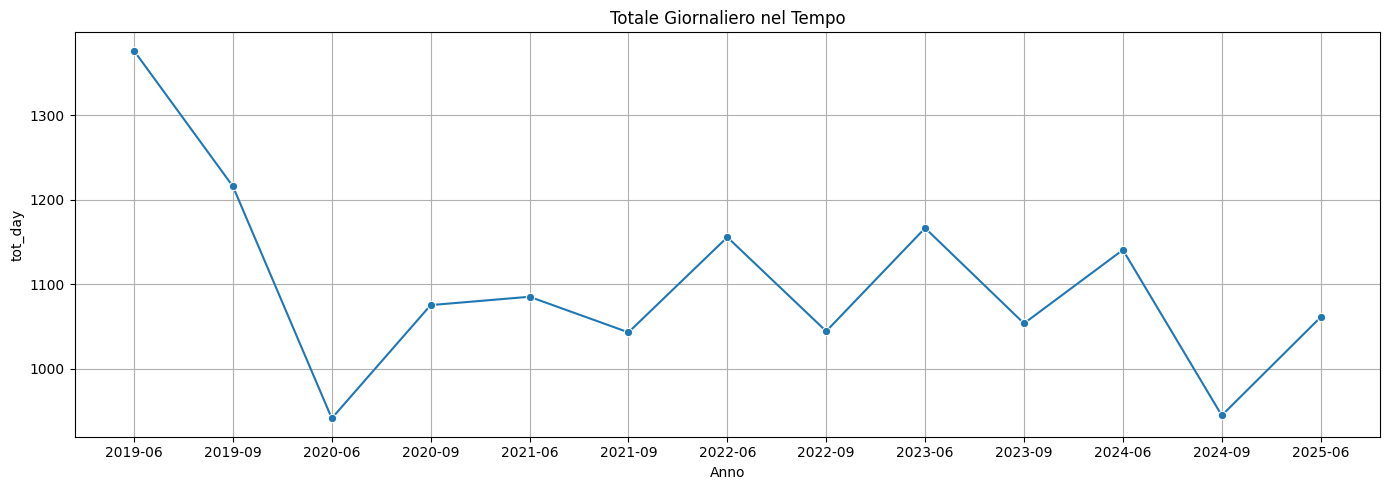

In [8]:
# TESTING FINAL VIZUALIZATION

plt.figure(figsize=(14, 5))
sns.lineplot(data=ds_viz, x="order", y="tot_day", marker="o")

plt.xticks(ticks=range(len(ds_viz)), labels=ds_viz["month"], rotation=0)

plt.title("Totale Giornaliero nel Tempo")
plt.xlabel("Anno")
plt.ylabel("tot_day")
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
print (len(ds_ordered["Nome via"].unique()))

318


In [ ]:
# PREPARING 30-VS-NON-30 GRAPH: BIKES

bike = pd.read_csv("./bike-trimmed.csv")
bike["data"] = pd.to_datetime(bike["data"])
print(bike.head(1))

bike_useful = bike[bike["data"].dt.year == 2024]
bike_grouped = (
    bike_useful.groupby("colonnina", as_index=False)
    .agg(
        totale_medio=("totale", "mean"),
        VEL2024=("VEL2024", "first")
    )
)

print(bike_grouped)

In [ ]:
# DATA CLEANING

bike_col = list(bike["colonnina"].unique())
bike_col.append("Laura Bassi")               
bike_col.remove("Laura_Bassi")   
print(bike_col)

In [ ]:
# DATA CLEANING FOR MATCHING DATAFRAMES (CARS AND BIKES)

bike_col_lower = [col.lower() for col in bike_col]

def find_streets(row):
    st = row["stname"].lower()
    for col in bike_col_lower:
        if col in st:
            return True
    return False

data_for_graph["has_colonnina"] = data_for_graph.apply(find_streets, axis=1)

df_filtrato = data_for_graph[data_for_graph["has_colonnina"]].copy()

df_filtrato = df_filtrato.drop(columns=["has_colonnina"])

C:\Users\nicco\AppData\Local\Temp\ipykernel_32568\2214452767.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_for_graph["has_colonnina"] = data_for_graph.apply(find_streets, axis=1)


In [ ]:
print(df_filtrato)

In [ ]:
# MERGING DFs

bike_col_lower = [col.lower() for col in bike_col]

def match_colonnina(stname):
    stname_lower = stname.lower()
    for col in bike_col_lower:
        if col in stname_lower:
            return col
    return None

df_filtrato["colonnina"] = df_filtrato["stname"].apply(match_colonnina)
bike_grouped["colonnina"] = bike_grouped["colonnina"].apply(match_colonnina)


df_filtrato = df_filtrato[df_filtrato["colonnina"].notna()]
df_finale = df_filtrato.merge(bike_grouped, on="colonnina", how="left")

df_finale = df_finale.dropna()


print(df_finale)

In [ ]:
# DROPPING UNUSED COLUMNS

df_car_bikes = df_finale[["tot_day", "totale_medio", "VEL2024"]]
df_car_bikes = df_car_bikes.rename(columns={"tot_day":"cars", "totale_medio":"bikes"})
print(df_car_bikes)

In [ ]:
# 30-ONLY DATA

df_30 = df_car_bikes.query("VEL2024 <= 30")
print(df_30)
df_30.to_csv("vie30.csv")

            cars       bikes  VEL2024
0    8978.200624  659.944444     30.0
1    7941.901694  659.944444     30.0
10   1574.936034  842.538251     30.0
11   1062.984588  842.538251     30.0
12   9873.559085  872.335294     30.0
..           ...         ...      ...
180  8374.265406  872.335294     30.0
181  8375.721716  804.878788     30.0
183  5134.526324  900.606061     30.0
185  5477.218430  600.704918     30.0
186  6922.747505  614.090909     30.0

[85 rows x 3 columns]


In [ ]:
# 50-OR-ABOVE DATA

df_non30 = df_car_bikes.query("VEL2024 > 30")
print(df_non30)
df_non30.to_csv("vie-non30.csv")

             cars        bikes  VEL2024
2     9823.837106   337.212121     50.0
3     8834.397696   337.212121     50.0
4     8172.529458   337.212121     50.0
5     8698.446302   337.212121     50.0
6     5294.515076   402.375000     50.0
..            ...          ...      ...
175   9820.428919   337.212121     50.0
176   3166.007844   337.212121     50.0
177   4127.183097   402.375000     50.0
184  17330.470302  2752.983607     50.0
188   9147.246640  2896.150273     50.0

[65 rows x 3 columns]


In [ ]:
# AVERAGES FOR EACH GROUP

d_30_cars_means = df_30["cars"].mean()
d_30_bikes_means = df_30["bikes"].mean()
d_non30_cars_means = df_non30["cars"].mean()
d_non30_bikes_means = df_non30["bikes"].mean()
df_30vsnon30 = pd.DataFrame(data={"cars (limit 30)": d_30_cars_means, "bikes (limit 30)": d_30_bikes_means, "cars (limit above 30)": d_non30_cars_means, "bikes (limit above 30)": d_non30_bikes_means}, index=[0])
print(df_30vsnon30)
df_30vsnon30.to_csv("df_30vsnon30.csv")

   cars (limit 30)  bikes (limit 30)  cars (limit above 30)  \
0      6139.703162        767.435919            9381.779277   

   bikes (limit above 30)  
0             1345.186624  


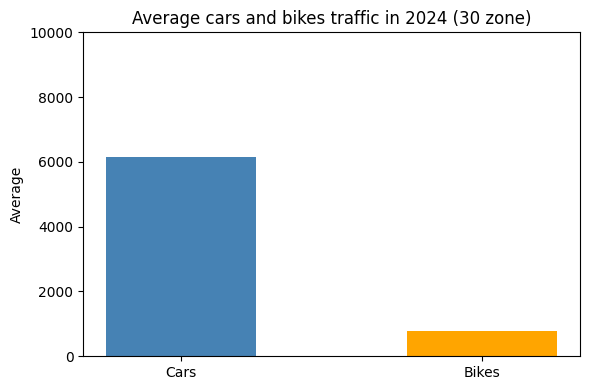

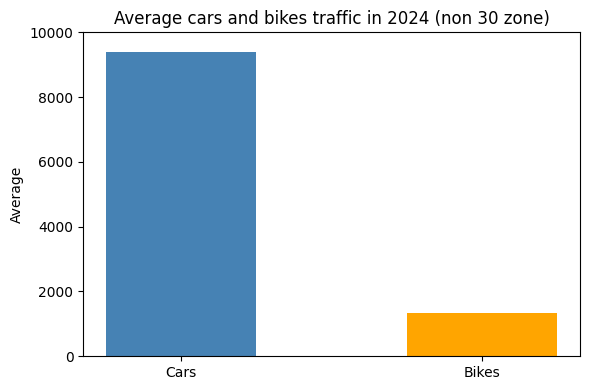

In [ ]:
# TESTING VISUALIZATION

for df in [df_30, df_non30]:
    cars_mean = df["cars"].mean()
    bikes_mean = df["bikes"].mean()

    # Preparo i dati per il grafico
    categorie = ["Cars", "Bikes"]
    valori = [cars_mean, bikes_mean]

    plt.figure(figsize=(6, 4))
    plt.bar(categorie, valori, color=["steelblue", "orange"], width=0.5)
    plt.ylim(top=10000)
    plt.ylabel("Average")
    if df["VEL2024"].iloc[0] == 30.0:
       plt.title("Average cars and bikes traffic in 2024 (30 zone)")
    else:
        plt.title("Average cars and bikes traffic in 2024 (non 30 zone)")
    plt.tight_layout()
    plt.show()